In [1]:
# first workflow

In [33]:
from langgraph.graph import StateGraph ,START,END
from typing import TypedDict


In [50]:
# define state
class BMIState(TypedDict):
    weight_kg:float
    height_m:float
    bmi:float
    category:str

In [43]:
def calculate_bmi(state:BMIState) -> BMIState:
    weight=state['weight_kg']
    height=state['height_m']
    bmi=weight/(height**2)
    state['bmi']=round(bmi,2)
    return {'bmi':bmi}

In [44]:
graph

In [69]:
def label_bmi(state:BMIState)-> BMIState:
    bmi=state['bmi']
    if  bmi<18.5:
        state['category']='underweight'
    elif 18.5<=bmi<25:
        state['category']='normal'
    elif 25<=bmi<30:
        state['category']='overhight'
    else:
        state['category']='obses'
    return state
    

In [70]:
# define graph
graph = StateGraph(BMIState)

# add nodes to your graph
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label_bmi',label_bmi)


# add edges
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi','label_bmi')
graph.add_edge('label_bmi', END)

# compile the graph
work = graph.compile()

In [71]:
initial_state = {'weight_kg': 60, 'height_m': 1.75}  # Corrected key & height
work.invoke(initial_state)

{'weight_kg': 60,
 'height_m': 1.75,
 'bmi': 19.591836734693878,
 'category': 'normal'}

In [72]:
initial_state = {'weight_kg': 60, 'height_m': 1.75}
work.invoke(initial_state)

{'weight_kg': 60,
 'height_m': 1.75,
 'bmi': 19.591836734693878,
 'category': 'normal'}

In [59]:
from IPython.display import Image,display
#Image(work.get_graph().draw_mermaid_png)

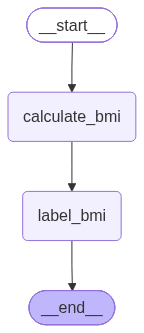

In [58]:
display(Image(work.get_graph().draw_mermaid_png()))

# llm workflow

In [73]:
from langgraph.graph import StateGraph,START,END
from langchain_ollama import ChatOllama
from typing  import TypedDict
from dotenv import load_dotenv

In [74]:
load_dotenv()

False

In [102]:
model=ChatOllama(model='smollm:135m')

In [120]:
# create a state
class llmstate(TypedDict):
    question:str
    answer:str
    

In [121]:
graph=StateGraph(llmstate)

In [122]:
def llm_qa(state:llmstate)->llmstate:
    # extarct the question
    question=state['question']
    # form a promt
    prompt=f' answer the following question {question}'
    #ask to that question to llm
    answer=model.invoke(prompt).content
    # update the answer in state
    state['answer']=answer
    return state
    

In [123]:
# add nodes
graph.add_node('llm_qa',llm_qa)
# add edeges
graph.add_edge(START,'llm_qa')
graph.add_edge('llm_qa',END)
chatbot=graph.compile()

In [125]:
intal_state={'question':'what is  the mass of earth?'}
final=chatbot.invoke(intal_state)
print(final['answer'])

The mass of Earth, which is approximately 6.93 × 10^24 kilograms (7.88 × 10^25 pounds), is a fundamental constant in physics and astronomy that plays a crucial role in our understanding of the universe. Here's what it means:

**What is mass?**

Mass is a measure of an object's resistance to changes in its motion or position due to gravity, acceleration, or other forces acting upon it. It can be thought of as the amount of matter that makes up an object and is proportional to its size and velocity. In other words, mass is the "amount" of stuff inside an object.

**What is the mass of Earth?**

The mass of Earth, which is approximately 6.93 × 10^24 kilograms (7.88 × 10^25 pounds), is a fundamental constant in physics and astronomy that has been extensively studied by scientists for over two centuries. It's a measure of the gravitational force between objects on Earth's surface, which is approximately 6.93 × 10^24 kilograms (7.88 × 10^25 pounds) per square meter.

**What are the dimension

# blogstate

In [144]:
class blogstate(TypedDict):
    title:str
    outline:str
    content:str
    

In [145]:
graph=StateGraph(blogstate)

In [146]:
def create_outline(state:blogstate)-> blogstate:
    # fecth the title
    title=state['title']
    # prompt=
    promt=f'Genrate a outline for a blog  on the  topic- {title}'
    outline=model.invoke(promt).content

    # update state
    state['outline']=outline
    return state

In [147]:
def create_blog(state:blogstate)->blogstate:
    # fetch
    title=state['title']
    outline=state['outline']
    pro=f'write a detailed blog on the title {title} using a follwing outline \n {outline}'
    content=model.invoke(pro).content
    state['content']=content

In [148]:
#  NODES
graph.add_node('create_outline',create_outline)
graph.add_node('create_blog',create_blog)
graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog',END)
path=graph.compile()

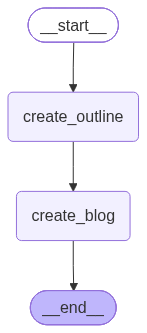

In [149]:
path

In [153]:
inatial_state={'title':'Rise of ai in india'}
res=path.invoke(inatial_state)
print(res['outline'])

Here is an outline for a blog on the rise of AI in India:

**Title:** "The Rise of AI in India"

I. Introduction (approx. 100 words)

* Briefly introduce the concept of AI and its significance in today's world
* Provide some background information about the Indian government, including their vision for AI adoption and challenges faced by them
* Thesis statement: While there is still much to be learned about the impact of AI on India, it is clear that AI has the potential to bring significant benefits to the country.

II. Background Information (approx. 100 words)

* Provide a brief overview of the Indian government's vision for AI adoption and challenges faced by them
* Discuss how these challenges have been addressed through various initiatives, such as the National Institute of Advanced Studies in India (NISSI), the Ministry of Electronics and Information Technology (MeTVI), and other organizations that support AI development.
* Highlight some examples of successful AI applications, 